## Introduction

This notebook runs **Scenario C QAOA (p=1)** on **AWS Braket SV1** and produces artifacts for comparison against the classical baseline from `09b_qubo_scenario_C_classical_baseline.ipynb`.

**Priorities**
- **Speed + quality**: small default parameter grid; optional “fuller demo” grid.
- **Resumable execution**: we **submit tasks** and write an ARN ledger first, then **decode from S3** `results.json` (avoids long blocking waits + clock drift / credential expiry).

**Outputs**
- `data/results/09c_sv1_tasks_scenario_C.csv` (task ledger / ARNs)
- `data/results/09c_sv1_selected_trials_scenario_C.csv` (selected NCT IDs)
- `data/results/09c_sv1_summary_scenario_C.csv` (best energy + metadata)
- `data/results/_09c_sv1_best_scenario_C.json` (full best payload)
- `outputs/figures/09c_sv1_energy_hist_pooled.png` (diagnostic histogram)


In [1]:
# ============================================================
# Cell 1 — Setup: imports, paths, AWS/Braket config, outputs
# ============================================================

from pathlib import Path
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import boto3
from braket.aws import AwsDevice

# --- Reproducibility ---
SEED = 0
np.random.seed(SEED)

# --- Project directories ---
QUBO_DIR = Path("data/qubo_scenarios")
RESULTS_DIR = Path("data/results")
FIG_DIR = Path("outputs/figures")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Inputs ---
PATH_QUBO = QUBO_DIR / "scenario_C_qubo.json"
if not PATH_QUBO.exists():
    raise FileNotFoundError(f"Missing: {PATH_QUBO}")

# --- Braket device (SV1) ---
SV1_ARN = "arn:aws:braket:::device/quantum-simulator/amazon/sv1"
device = AwsDevice(SV1_ARN)
print("Braket device:", device.name)
print("Braket ARN:", SV1_ARN)

# --- Braket results destination (MUST be amazon-braket-* bucket) ---
# Use the Braket-managed bucket for your account/region.
BRAKET_BUCKET = "amazon-braket-us-west-2-581610642254"
BRAKET_PREFIX = "clinical-trials-data/results/sv1_tasks/scenario_C"
s3_destination_folder = (BRAKET_BUCKET, BRAKET_PREFIX)

# --- Outputs ---
OUT_TASKS     = RESULTS_DIR / "09c_sv1_tasks_scenario_C.csv"
OUT_SELECTED  = RESULTS_DIR / "09c_sv1_selected_trials_scenario_C.csv"
OUT_SUMMARY   = RESULTS_DIR / "09c_sv1_summary_scenario_C.csv"
OUT_BEST_JSON = RESULTS_DIR / "_09c_sv1_best_scenario_C.json"
OUT_FIG       = FIG_DIR / "09c_sv1_energy_hist_pooled.png"

print("UTC now:", datetime.now(timezone.utc).isoformat())
print("QUBO:", PATH_QUBO)
print("SV1 results S3:", f"s3://{BRAKET_BUCKET}/{BRAKET_PREFIX}")


Braket device: SV1
Braket ARN: arn:aws:braket:::device/quantum-simulator/amazon/sv1
UTC now: 2025-12-04T11:25:07.819186+00:00
QUBO: data/qubo_scenarios/scenario_C_qubo.json
SV1 results S3: s3://amazon-braket-us-west-2-581610642254/clinical-trials-data/results/sv1_tasks/scenario_C


### What Cell 1 Just Did

- Imported libraries and set a random seed for reproducibility.
- Defined standard project paths for inputs/outputs.
- Initialized the **Braket SV1** device.
- Set the **required** `amazon-braket-*` results bucket/prefix for task outputs.
- Declared the artifact filenames this notebook will write.


In [2]:
# ============================================================
# Cell 2 — Load + robust-parse Scenario C QUBO JSON into (Q, nct_ids)
# ============================================================

def parse_qubo_payload(payload):
    """
    Robust QUBO parser. Returns (Q, nct_ids, meta).

    Supports:
      - {"Q": [[...]], "nct_ids":[...]}
      - {"qubo_matrix": [[...]], "nct_ids":[...]}
      - {"qubo": {"(i,j)": v, ...}, "n": N, "nct_ids":[...]}
      - {"linear": {...}, "quadratic": {...}, "n":N}
      - One-level wrappers: {"payload": {...}} etc.
    """
    meta = {}

    # unwrap single-key wrapper
    if isinstance(payload, dict) and len(payload) == 1:
        only_key = next(iter(payload.keys()))
        if isinstance(payload[only_key], dict) and any(
            k in payload[only_key] for k in ["Q", "qubo_matrix", "qubo", "linear", "quadratic", "matrix"]
        ):
            payload = payload[only_key]

    if not isinstance(payload, dict):
        raise ValueError("QUBO payload must be a JSON object (dict).")

    # meta
    if "meta" in payload and isinstance(payload["meta"], dict):
        meta.update(payload["meta"])
    for k in ["scenario", "K", "penalty_A", "lambda_cost", "lambda_safety", "notes", "created_at", "n"]:
        if k in payload:
            meta[k] = payload[k]

    # ids
    nct_ids = None
    for key in ["nct_ids", "trial_ids", "ids", "variables"]:
        if key in payload and isinstance(payload[key], list):
            nct_ids = payload[key]
            break
    if nct_ids is None and "nct_ids" in meta and isinstance(meta.get("nct_ids"), list):
        nct_ids = meta["nct_ids"]

    # dense
    for key in ["Q", "qubo_matrix", "matrix"]:
        if key in payload:
            Q = np.array(payload[key], dtype=float)
            if Q.ndim != 2 or Q.shape[0] != Q.shape[1]:
                raise ValueError(f"{key} must be a square matrix. Got {Q.shape}")
            n = Q.shape[0]
            if nct_ids is None:
                nct_ids = [f"var_{i}" for i in range(n)]
            if len(nct_ids) != n:
                raise ValueError(f"nct_ids length {len(nct_ids)} != n {n}")
            return Q, list(nct_ids), meta

    # dict-of-terms
    n = payload.get("n") or meta.get("n") or (len(nct_ids) if nct_ids else None)
    if n is None:
        raise ValueError("Could not infer QUBO dimension n.")

    Q = np.zeros((int(n), int(n)), dtype=float)

    if "qubo" in payload and isinstance(payload["qubo"], dict):
        for k, v in payload["qubo"].items():
            s = str(k).strip().replace("(", "").replace(")", "").replace("[", "").replace("]", "")
            parts = [p.strip() for p in s.split(",") if p.strip()]
            if len(parts) != 2:
                continue
            i, j = int(parts[0]), int(parts[1])
            Q[i, j] += float(v)
        if nct_ids is None:
            nct_ids = [f"var_{i}" for i in range(int(n))]
        return Q, list(nct_ids), meta

    if "linear" in payload and isinstance(payload["linear"], dict):
        for i, v in payload["linear"].items():
            Q[int(i), int(i)] += float(v)

    if "quadratic" in payload and isinstance(payload["quadratic"], dict):
        for k, v in payload["quadratic"].items():
            s = str(k).strip().replace("(", "").replace(")", "").replace("[", "").replace("]", "")
            parts = [p.strip() for p in s.split(",") if p.strip()]
            if len(parts) != 2:
                continue
            i, j = int(parts[0]), int(parts[1])
            Q[i, j] += float(v)

    if nct_ids is None:
        nct_ids = [f"var_{i}" for i in range(int(n))]

    return Q, list(nct_ids), meta


payload = json.loads(PATH_QUBO.read_text())
Q, nct_ids, meta = parse_qubo_payload(payload)
n = Q.shape[0]

print("Parsed Scenario C QUBO.")
print("n =", n, "| nct_ids =", len(nct_ids))
print("Q nnz≈", int(np.count_nonzero(Q)))


Parsed Scenario C QUBO.
n = 60 | nct_ids = 60
Q nnz≈ 3600


### What Cell 2 Just Did

- Loaded `data/qubo_scenarios/scenario_C_qubo.json`.
- Parsed it into a dense square matrix `Q` and an aligned `nct_ids` mapping.
- Printed basic size/sparsity stats so we can decide whether pooling is needed for SV1.


In [3]:
# ============================================================
# Cell 3 — Enforce SV1 34-qubit limit via pooling (fast + explainable)
# ============================================================

SV1_QUBIT_CAP = 34

def pool_best_diag(Qfull: np.ndarray, cap: int) -> list[int]:
    """Pick indices with most-negative diagonals (fast heuristic)."""
    diag = np.diag(Qfull).copy()
    idx = np.argsort(diag)  # most negative first
    return idx[:cap].astype(int).tolist()

def submatrix(Qfull: np.ndarray, idx: list[int]) -> np.ndarray:
    return Qfull[np.ix_(idx, idx)].copy()

if n <= SV1_QUBIT_CAP:
    pool_idx = list(range(n))
    pool_strategy = "none_needed"
else:
    pool_idx = pool_best_diag(Q, SV1_QUBIT_CAP)
    pool_strategy = "best_diag"

Q_sub = submatrix(Q, pool_idx)
n_sub = Q_sub.shape[0]
nct_ids_sub = [nct_ids[i] for i in pool_idx]

print("Pooling strategy:", pool_strategy)
print("n_full:", n, "| n_pool:", n_sub)


Pooling strategy: best_diag
n_full: 60 | n_pool: 34


### What Cell 3 Just Did

- Enforced SV1’s **34-qubit** circuit limit.
- If Scenario C has more than 34 variables, built a pooled subproblem using a fast heuristic.
- Created `Q_sub` + `nct_ids_sub`, which are the objects we will actually send to SV1.


In [8]:
# ============================================================
# Cell 4 — QUBO → Ising + p=1 QAOA circuit builder (Braket-safe measurement)
# ============================================================

from braket.circuits import Circuit

def qubo_to_ising(Qmat: np.ndarray):
    """
    Map QUBO x in {0,1} to Ising z in {-1,+1} via x = (1 - z)/2.
    Returns (offset, h, J):
      H(z) = offset + sum_i h_i z_i + sum_{i<j} J_ij z_i z_j
    """
    Qs = 0.5 * (Qmat + Qmat.T)
    n = Qs.shape[0]

    h = np.zeros(n, dtype=float)
    J = {}
    offset = 0.0

    # diagonal terms
    for i in range(n):
        offset += Qs[i, i] * 0.5
        h[i] += -Qs[i, i] * 0.5

    # off-diagonals
    for i in range(n):
        for j in range(i + 1, n):
            q = Qs[i, j]
            if abs(q) < 1e-12:
                continue
            offset += q / 4.0
            h[i] += -q / 4.0
            h[j] += -q / 4.0
            J[(i, j)] = q / 4.0

    return offset, h, J

def qaoa_circuit_p1_braket(h: np.ndarray, J: dict, gamma: float, beta: float) -> Circuit:
    """
    p=1 QAOA circuit on Braket.

    Measurement compatibility:
      Some braket versions expose Circuit.measure(qubit) (1 arg),
      and do NOT accept Circuit.measure(qubit, classical_bit).
    """
    n = len(h)
    circ = Circuit()

    # |+>^n
    for q in range(n):
        circ.h(q)

    # cost unitary: single-qubit Z terms
    for i in range(n):
        if abs(h[i]) > 1e-12:
            circ.rz(i, 2.0 * gamma * h[i])

    # cost unitary: ZZ couplers
    for (i, j), Jij in J.items():
        circ.zz(i, j, 2.0 * gamma * Jij)

    # mixer
    for q in range(n):
        circ.rx(q, 2.0 * beta)

    # measurement (version-safe)
    for q in range(n):
        circ.measure(q)

    return circ

offset, h, J = qubo_to_ising(Q_sub)
print("Ising built for pooled instance.")
print("n_pool =", len(h), "| couplers =", len(J))


Ising built for pooled instance.
n_pool = 34 | couplers = 561


### What Cell 4 Just Did

- Converted the pooled QUBO `Q_sub` into an Ising Hamiltonian `(h, J)`.
- Defined a Braket-compatible **p=1 QAOA** circuit builder using explicit measurements (avoids the `measure_all` error you hit earlier).


In [9]:
# ============================================================
# Cell 5 — Submit SV1 tasks (non-blocking) + write task ledger
# ============================================================

# --- Speed/quality knob ---
FAST_MODE = True

if FAST_MODE:
    SHOTS = 100
    GAMMA_GRID = [0.6, 1.2]
    BETA_GRID  = [0.6, 1.2]   # 4 tasks total
else:
    SHOTS = 200
    GAMMA_GRID = [0.4, 0.9, 1.4]
    BETA_GRID  = [0.4, 0.9, 1.4]  # 9 tasks total

print("UTC now:", datetime.now(timezone.utc).isoformat())
print("Mode:", "FAST" if FAST_MODE else "FULL")
print("shots:", SHOTS, "| tasks:", len(GAMMA_GRID) * len(BETA_GRID))

# --- Smoke test: ensure circuit builds with your installed braket version ---
_smoke = qaoa_circuit_p1_braket(h, J, gamma=float(GAMMA_GRID[0]), beta=float(BETA_GRID[0]))
print("Smoke-test circuit built. Qubits:", len(h))

submitted = []
k = 0
total = len(GAMMA_GRID) * len(BETA_GRID)

for gamma in GAMMA_GRID:
    for beta in BETA_GRID:
        k += 1
        circ = qaoa_circuit_p1_braket(h, J, gamma=float(gamma), beta=float(beta))

        task = device.run(
            circ,
            shots=int(SHOTS),
            s3_destination_folder=s3_destination_folder
        )

        submitted.append({
            "scenario": "C",
            "gamma": float(gamma),
            "beta": float(beta),
            "shots": int(SHOTS),
            "task_arn": task.id,
            "created_utc": datetime.now(timezone.utc).isoformat(),
            "n_full": int(n),
            "n_pool": int(n_sub),
            "pool_strategy": pool_strategy,
            "braket_bucket": BRAKET_BUCKET,
            "braket_prefix": BRAKET_PREFIX,
        })

        print(f"[{k}/{total}] submitted:", task.id)

tasks_df = pd.DataFrame(submitted)
tasks_df.to_csv(OUT_TASKS, index=False)
print("Wrote:", OUT_TASKS)
display(tasks_df)


UTC now: 2025-12-04T11:33:07.363128+00:00
Mode: FAST
shots: 100 | tasks: 4
Smoke-test circuit built. Qubits: 34
[1/4] submitted: arn:aws:braket:us-west-2:581610642254:quantum-task/04b33e82-35e9-418f-872b-25a7012f6bac
[2/4] submitted: arn:aws:braket:us-west-2:581610642254:quantum-task/f0269282-1e08-406e-99d2-6feb10cdd4f8
[3/4] submitted: arn:aws:braket:us-west-2:581610642254:quantum-task/2e855d38-5da3-459e-a800-7bbc35148b38
[4/4] submitted: arn:aws:braket:us-west-2:581610642254:quantum-task/6b9614ad-e00d-4331-97d1-0961d1aea55b
Wrote: data/results/09c_sv1_tasks_scenario_C.csv


,scenario,gamma,beta,shots,task_arn,created_utc,n_full,n_pool,pool_strategy,braket_bucket,braket_prefix
0,C,0.6,0.6,100,arn:aws:braket:us-west-2:581610642254:quantum-...,2025-12-04T11:33:08.874192+00:00,60,34,best_diag,amazon-braket-us-west-2-581610642254,clinical-trials-data/results/sv1_tasks/scenario_C
1,C,0.6,1.2,100,arn:aws:braket:us-west-2:581610642254:quantum-...,2025-12-04T11:33:09.249515+00:00,60,34,best_diag,amazon-braket-us-west-2-581610642254,clinical-trials-data/results/sv1_tasks/scenario_C
2,C,1.2,0.6,100,arn:aws:braket:us-west-2:581610642254:quantum-...,2025-12-04T11:33:09.607920+00:00,60,34,best_diag,amazon-braket-us-west-2-581610642254,clinical-trials-data/results/sv1_tasks/scenario_C
3,C,1.2,1.2,100,arn:aws:braket:us-west-2:581610642254:quantum-...,2025-12-04T11:33:09.963411+00:00,60,34,best_diag,amazon-braket-us-west-2-581610642254,clinical-trials-data/results/sv1_tasks/scenario_C


### What Cell 5 Just Did

- Chose a **parameter grid** for QAOA `(gamma, beta)` and a **shot count** (`SHOTS`) using `FAST_MODE` as the main speed/quality switch.
- For each `(gamma, beta)` pair, built a **p=1 QAOA circuit** with your version-safe `qaoa_circuit_p1_braket(...)`.
- Submitted each circuit to **AWS Braket SV1** via `device.run(...)`, writing results to:
  - `s3://amazon-braket-us-west-2-581610642254/clinical-trials-data/results/sv1_tasks/scenario_C/`
- Captured the returned **task ARNs** and saved a resumable ledger to:
  - `data/results/09c_sv1_tasks_scenario_C.csv`

Why this matters: the task ledger lets you safely disconnect/restart and still recover results later by decoding `results.json` from S3.


Found 3 results.json in s3://amazon-braket-us-west-2-581610642254/clinical-trials-data/results/sv1_tasks/scenario_C


,bitstring,energy_pool,bit_order,results_json_key
2,0000000010000000000000000001100010,-2600.0,LR,clinical-trials-data/results/sv1_tasks/scenari...
0,1000000000001010000100110000010000,-2410.0,RL,clinical-trials-data/results/sv1_tasks/scenari...
1,0100001110000001011000000010000010,-1270.0,LR,clinical-trials-data/results/sv1_tasks/scenari...


Wrote:
  - data/results/09c_sv1_tasks_scenario_C.csv
  - data/results/09c_sv1_selected_trials_scenario_C.csv
  - data/results/09c_sv1_summary_scenario_C.csv
  - data/results/_09c_sv1_best_scenario_C.json


,scenario,n_full,n_pool,pool_strategy,shots,qubo_energy_pool_best,qubo_energy_full,selected_n,bit_order_used,results_json_key,braket_bucket,braket_prefix
0,C,60,34,best_diag,100,-2600.0,-2600.0,4,LR,clinical-trials-data/results/sv1_tasks/scenari...,amazon-braket-us-west-2-581610642254,clinical-trials-data/results/sv1_tasks/scenario_C


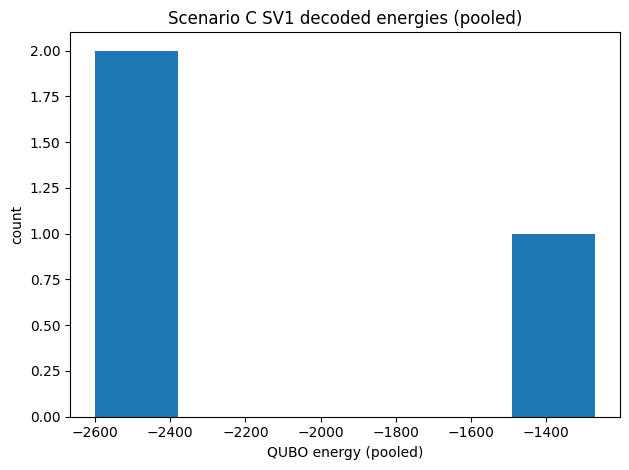

Saved: outputs/figures/09c_sv1_energy_hist_pooled.png


In [10]:
# ============================================================
# Cell 6 — Decode from S3 results.json, select best, write artifacts
# ============================================================

# NOTE: This cell does NOT call task.result(). It reads completed results from S3.
# This avoids long-running blocking loops + signature expiry.

s3 = boto3.client("s3", region_name="us-west-2")

def list_results_json(bucket: str, prefix: str) -> list[str]:
    keys = []
    token = None
    while True:
        kwargs = {"Bucket": bucket, "Prefix": prefix}
        if token:
            kwargs["ContinuationToken"] = token
        resp = s3.list_objects_v2(**kwargs)

        for it in resp.get("Contents", []):
            key = it["Key"]
            if key.endswith("results.json"):
                keys.append(key)

        if resp.get("IsTruncated"):
            token = resp.get("NextContinuationToken")
        else:
            break
    return sorted(keys)

def extract_samples(obj: dict) -> list[str]:
    """
    Supports Braket results.json common shapes:
      - measurementCounts (dict): {"0101...": count, ...}
      - measurements (list): [[0,1,0,...], ...]  or ["0101...", ...]
    """
    # counts-style
    if isinstance(obj.get("measurementCounts"), dict):
        out = []
        for k, v in obj["measurementCounts"].items():
            out.extend([str(k).replace(" ", "")] * int(v))
        return out

    # sv1 often: "measurements": list of bit-arrays per shot
    if isinstance(obj.get("measurements"), list) and obj["measurements"]:
        m = obj["measurements"]
        if isinstance(m[0], (list, tuple, np.ndarray)):
            return ["".join(str(int(b)) for b in row) for row in m]
        if isinstance(m[0], str):
            return [str(x).replace(" ", "") for x in m]

    return []

def qubo_energy(Qmat: np.ndarray, x01: np.ndarray) -> float:
    x = x01.astype(int)
    return float(x.T @ Qmat @ x)

def decode_best(Qmat: np.ndarray, samples: list[str]) -> dict | None:
    """
    Find best-energy bitstring from samples.
    Also tries both bit orders (LR vs reversed) and keeps the better one.

    Returns:
      {"bitstring": str, "energy_pool": float, "bit_order": "LR"|"RL"}
    """
    n_ = Qmat.shape[0]
    best = None

    for raw in samples:
        s = str(raw).replace(" ", "").strip()
        if len(s) != n_:
            continue
        if not set(s).issubset({"0", "1"}):
            continue

        x_lr = np.array([int(ch) for ch in s], dtype=int)
        e_lr = qubo_energy(Qmat, x_lr)

        x_rl = x_lr[::-1]
        e_rl = qubo_energy(Qmat, x_rl)

        if e_lr <= e_rl:
            cand = {"bitstring": s, "energy_pool": float(e_lr), "bit_order": "LR"}
        else:
            cand = {"bitstring": s[::-1], "energy_pool": float(e_rl), "bit_order": "RL"}

        if best is None or cand["energy_pool"] < best["energy_pool"]:
            best = cand

    return best

# --- gather results.json files ---
keys = list_results_json(BRAKET_BUCKET, BRAKET_PREFIX)
print(f"Found {len(keys)} results.json in s3://{BRAKET_BUCKET}/{BRAKET_PREFIX}")

rows = []
best_global = None

for key in keys:
    obj = json.loads(s3.get_object(Bucket=BRAKET_BUCKET, Key=key)["Body"].read().decode("utf-8"))
    samples = extract_samples(obj)
    if not samples:
        continue

    best = decode_best(Q_sub, samples)
    if best is None:
        continue

    best["results_json_key"] = key
    rows.append(best)

    if best_global is None or best["energy_pool"] < best_global["energy_pool"]:
        best_global = best

decoded_df = pd.DataFrame(rows).sort_values("energy_pool", ascending=True) if rows else pd.DataFrame()
display(decoded_df.head(10))

if best_global is None:
    raise RuntimeError(
        "No decodable results.json found yet.\n"
        "Your tasks may still be RUNNING/QUEUED. Re-run this cell later."
    )

# --- pooled -> full mapping ---
x_pool = np.array([int(ch) for ch in best_global["bitstring"]], dtype=int)
x_full = np.zeros(n, dtype=int)
for local_i, full_i in enumerate(pool_idx):
    x_full[full_i] = x_pool[local_i]

E_full = float(x_full.T @ Q @ x_full)
selected_ids = [nct_ids[i] for i in range(n) if x_full[i] == 1]

pd.DataFrame({"nct_id": selected_ids}).to_csv(OUT_SELECTED, index=False)

summary = pd.DataFrame([{
    "scenario": "C",
    "n_full": int(n),
    "n_pool": int(n_sub),
    "pool_strategy": pool_strategy,
    "shots": int(SHOTS),
    "qubo_energy_pool_best": float(best_global["energy_pool"]),
    "qubo_energy_full": float(E_full),
    "selected_n": int(x_full.sum()),
    "bit_order_used": best_global["bit_order"],
    "results_json_key": best_global["results_json_key"],
    "braket_bucket": BRAKET_BUCKET,
    "braket_prefix": BRAKET_PREFIX,
}])
summary.to_csv(OUT_SUMMARY, index=False)

best_payload = {
    "scenario": "C",
    "source": "sv1_results_json_resume",
    "bitstring_pool": best_global["bitstring"],
    "pool_idx": pool_idx,
    "pool_strategy": pool_strategy,
    "n_full": int(n),
    "n_pool": int(n_sub),
    "shots": int(SHOTS),
    "qubo_energy_pool_best": float(best_global["energy_pool"]),
    "qubo_energy_full": float(E_full),
    "selected_n": int(x_full.sum()),
    "selected_ids": selected_ids,
    "bit_order_used": best_global["bit_order"],
    "results_json_key": best_global["results_json_key"],
    "braket_task_bucket": BRAKET_BUCKET,
    "braket_task_prefix": BRAKET_PREFIX,
}
OUT_BEST_JSON.write_text(json.dumps(best_payload, indent=2))

print("Wrote:")
print("  -", OUT_TASKS)
print("  -", OUT_SELECTED)
print("  -", OUT_SUMMARY)
print("  -", OUT_BEST_JSON)
display(summary)

# --- diagnostic histogram of decoded energies ---
if not decoded_df.empty:
    plt.figure()
    plt.hist(decoded_df["energy_pool"].astype(float), bins=min(20, max(6, len(decoded_df))))
    plt.title("Scenario C SV1 decoded energies (pooled)")
    plt.xlabel("QUBO energy (pooled)")
    plt.ylabel("count")
    plt.tight_layout()
    plt.savefig(OUT_FIG, dpi=160)
    plt.show()
    print("Saved:", OUT_FIG)


### What Cell 6 Just Did

- Searched your Braket results prefix in S3 for `results.json` files.
- Extracted measurement samples from each result (supports both `measurementCounts` and `measurements` formats).
- Decoded each task’s samples to find the **best QUBO-energy bitstring** for the pooled instance (`Q_sub`), including checking **bit-order** (LR vs reversed).
- Expanded the pooled solution back into the **full Scenario C** variable space and computed:
  - best pooled energy
  - full-space energy
  - selected trial IDs
- Wrote final artifacts:
  - `data/results/09c_sv1_selected_trials_scenario_C.csv`
  - `data/results/09c_sv1_summary_scenario_C.csv`
  - `data/results/_09c_sv1_best_scenario_C.json`
- Saved a diagnostic histogram to `outputs/figures/09c_sv1_energy_hist_pooled.png`
